In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import LoadImage
from pathlib import PureWindowsPath, Path
import torch
import nibabel as nib

In [2]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/Preprocessing/Segmentation_data/full_pairs.csv")

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4510 entries, 0 to 4509
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   SubjectKeyRadiology  4510 non-null   str   
 1   ExamDate             4510 non-null   str   
 2   arterial_image       2704 non-null   str   
 3   portal_image         3878 non-null   str   
 4   arterial_organs      2704 non-null   str   
 5   portal_organs        3878 non-null   str   
 6   arterial_lesion      2704 non-null   str   
 7   portal_lesion        3878 non-null   str   
 8   arterial_lesionfree  2072 non-null   str   
 9   portal_lesionfree    2072 non-null   str   
 10  lesion_visible_both  2072 non-null   object
 11  split                4510 non-null   str   
 12  present_phase        2438 non-null   str   
 13  output_dir           4510 non-null   str   
 14  base_name_raw        4510 non-null   str   
 15  dups_count           4510 non-null   int64 
 16  base_name        

In [ ]:
data.iloc[1051, :]

SubjectKeyRadiology                                   NKI-d23231-00-0297
ExamDate                                                      2017-12-20
arterial_image         /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
portal_image           /mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
arterial_organs        /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
portal_organs          /mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
arterial_lesion        /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
portal_lesion          /mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
arterial_lesionfree                                                   No
portal_lesionfree                                                     No
lesion_visible_both                                                 True
split                                                              train
present_phase                                                        NaN
output_dir             /mnt/rhea/data_private/IRBd2

In [23]:
data.iloc[300, :]

SubjectKeyRadiology                                   NKI-d23231-00-0078
ExamDate                                                      2008-12-02
arterial_image         /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
portal_image           /mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
arterial_organs        /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
portal_organs          /mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
arterial_lesion        /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
portal_lesion          /mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
arterial_lesionfree                                                   No
portal_lesionfree                                                     No
lesion_visible_both                                                 True
split                                                               test
present_phase                                                        NaN
output_dir             /mnt/rhea/data_private/IRBd2

In [20]:
def load(path):
    loader = LoadImage(image_only=True, ensure_channel_first=True)
    if path is None or isinstance(path, float):
        return None
    img=loader(path)
    return torch.as_tensor(img)

def window_ct(img, center=None, width=None):
    if center is None and width is None:
        return img.clip(-70, 180)
    else:
        low = center - width / 2
        high = center + width / 2
        return img.clip(low, high)


def load_pair(df, i=0, dataset = "reg"):
    if dataset == "reg":
        row = df.iloc[i]

        a_img = load(row["arterial_image"])
        p_img = load(row["portal_image"])

        a_organs = load(row["arterial_organs"])
        a_liver = (a_organs[0] == 5).unsqueeze(0)
        p_liver = load(row["portal_organs"])

        a_lesion = load(row["arterial_lesion"])
        p_lesion = load(row["portal_lesion"])
        

        return a_img, p_img, a_liver, p_liver, a_lesion, p_lesion
    
    elif dataset == "proc":
        output_path = df.iloc[i, -1]

        data = torch.load(output_path)

        a_img = data["arterial_image"]
        p_img = data["portal_image"]

        a_liver = data["arterial_liver"]
        p_liver = data["portal_liver"]

        a_lesion = data["arterial_lesion"]
        p_lesion = data["portal_lesion"]
        

        return a_img, p_img, a_liver, p_liver, a_lesion, p_lesion
    
    else:
        raise ValueError("Dataset must be eihter \"reg\" for registered or \"proc\" for preprocessed data")

def visualize_row(df, i=0, slice_idx=None, dataset = "reg"):

    # -----------------------
    # LOAD EVERYTHING
    # -----------------------
    a_img, p_img, a_liver, p_liver, a_lesion, p_lesion = load_pair(df, i, dataset = dataset)

    # -----------------------
    # sanity check
    # -----------------------
    if a_img is None or p_img is None:
        raise ValueError("Missing CT images")

    # -----------------------
    # pick slice
    # -----------------------
    if slice_idx is None:
        slice_idx = a_img.shape[1] // 2

    a_slice = a_img[0, :, :, slice_idx]
    p_slice = p_img[0, :, :, slice_idx]

    # -----------------------
    # mask slices
    # -----------------------
    def sl(x):
        return None if x is None else x[0, :, :, slice_idx] > 0

    a_l = sl(a_liver)
    p_l = sl(p_liver)
    a_ls = sl(a_lesion)
    p_ls = sl(p_lesion)


    # -----------------------
    # PLOT 1: CT
    # -----------------------
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(np.rot90(a_slice), cmap="gray") if dataset == "proc" else ax[0].imshow(np.rot90(window_ct(a_slice)), cmap="gray")
    ax[0].set_title("Arterial")
    ax[0].axis("off")

    ax[1].imshow(np.rot90(p_slice), cmap="gray") if dataset == "proc" else ax[1].imshow(np.rot90(window_ct(p_slice)), cmap="gray")
    ax[1].set_title("Portal")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

    # -----------------------
    # PLOT 2: overlays
    # -----------------------
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    # =======================
    # ARTERIAL
    # =======================
    ct_a = np.rot90(a_slice.cpu().numpy(), k=1) if dataset == "proc" else np.rot90(window_ct(a_slice.cpu().numpy()), k=1)

    ax[0].imshow(ct_a, cmap="gray")

    # liver overlay (RED)
    if a_l is not None:

        liver_mask = np.rot90(a_l.cpu().numpy(), k=1)

        liver_rgba = np.zeros((*liver_mask.shape, 4))

        liver_rgba[..., 0] = 1.0   # red
        liver_rgba[..., 3] = liver_mask * 0.4

        ax[0].imshow(liver_rgba)

    # lesion overlay (BLUE)
    if a_ls is not None:

        lesion_mask = np.rot90(a_ls.cpu().numpy(), k=1)

        lesion_rgba = np.zeros((*lesion_mask.shape, 4))

        lesion_rgba[..., 2] = 1.0   # blue
        lesion_rgba[..., 3] = lesion_mask * 0.4

        ax[0].imshow(lesion_rgba)

    ax[0].set_title("Arterial + masks")
    ax[0].axis("off")


    # =======================
    # PORTAL
    # =======================
    ct_p = np.rot90(p_slice.cpu().numpy(), k=1) if dataset == "proc" else np.rot90(window_ct(p_slice.cpu().numpy()), k=1)


    ax[1].imshow(ct_p, cmap="gray")

    # liver overlay (RED)
    if p_l is not None:

        liver_mask = np.rot90(p_l.cpu().numpy(), k=1)

        liver_rgba = np.zeros((*liver_mask.shape, 4))

        liver_rgba[..., 0] = 1.0
        liver_rgba[..., 3] = liver_mask * 0.4

        ax[1].imshow(liver_rgba)

    # lesion overlay (BLUE)
    if p_ls is not None:

        lesion_mask = np.rot90(p_ls.cpu().numpy(), k=1)

        lesion_rgba = np.zeros((*lesion_mask.shape, 4))

        lesion_rgba[..., 2] = 1.0
        lesion_rgba[..., 3] = lesion_mask * 0.4

        ax[1].imshow(lesion_rgba)

    ax[1].set_title("Portal + masks")
    ax[1].axis("off")




    plt.tight_layout()
    plt.show()

    print("Shapes:", a_img.shape, p_img.shape, a_liver.shape, p_liver.shape, a_lesion.shape, p_lesion.shape)


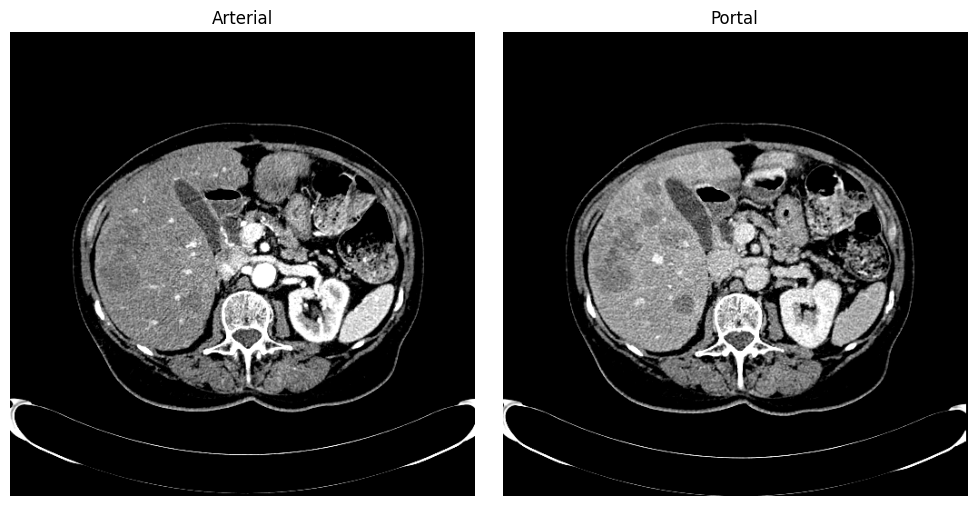

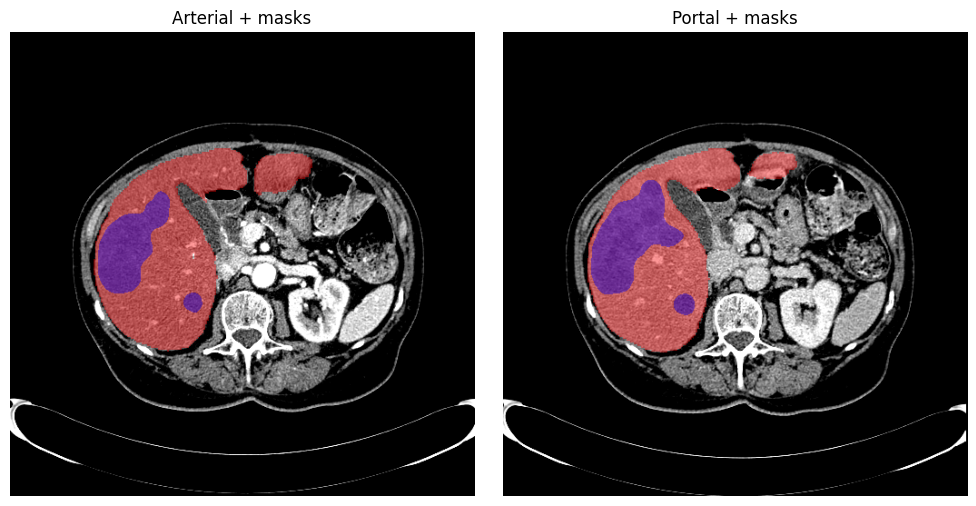

Shapes: torch.Size([1, 512, 512, 146]) torch.Size([1, 512, 512, 146]) torch.Size([1, 512, 512, 146]) torch.Size([1, 512, 512, 146]) torch.Size([1, 512, 512, 146]) torch.Size([1, 512, 512, 146])


/tmp/ipykernel_645148/1905742941.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(output_path)


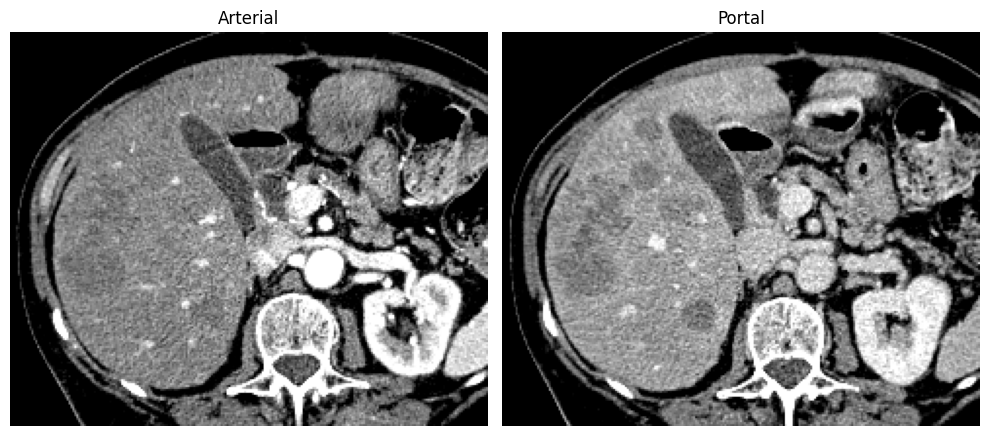

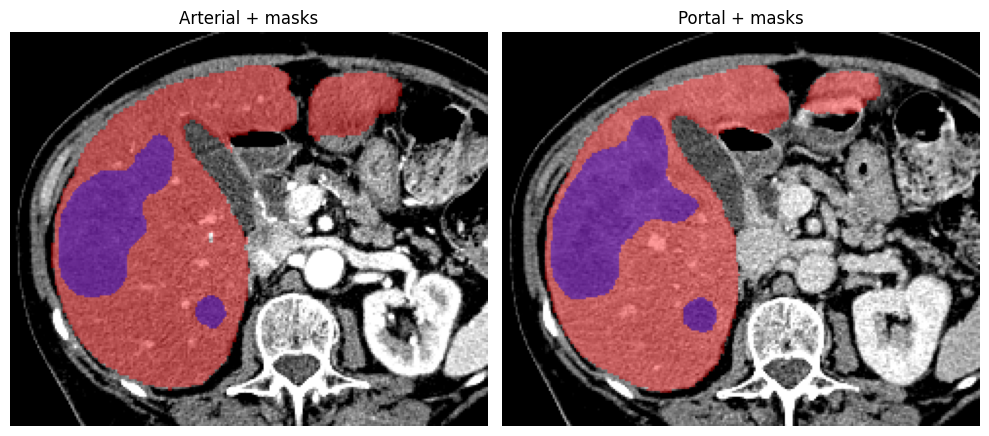

Shapes: torch.Size([1, 245, 202, 244]) torch.Size([1, 245, 202, 244]) torch.Size([1, 245, 202, 244]) torch.Size([1, 245, 202, 244]) torch.Size([1, 245, 202, 244]) torch.Size([1, 245, 202, 244])


In [6]:
visualize_row(data, i=1051, slice_idx=104, dataset = "reg")
visualize_row(data, i=1051, slice_idx=120, dataset = "proc")


In [7]:
a_img, p_img, a_liver, p_liver, a_lesion, p_lesion = load_pair(data, i=1051, dataset="reg")

In [34]:

def lesion_volume(lesion):
    """
    Returns lesion physical volume in cm3.
    """
    if lesion is None:
        return 0.0

    spacing = lesion.pixdim
    print(f"Spacing: {spacing}")
    voxels = (lesion > 0).float().sum().item()
    volume = voxels * spacing[0] * spacing[1] * spacing[2] * 0.001

    return volume

In [9]:
a_vol = lesion_volume(a_lesion)
p_vol = lesion_volume(p_lesion)
print(f"Initial volumes: {a_vol}, {p_vol}")

Spacing: tensor([0.7461, 0.7461, 3.0000], dtype=torch.float64)
Spacing: tensor([0.7461, 0.7461, 3.0000], dtype=torch.float64)
Initial volumes: 217.01062632751464, 293.72226036071777


In [10]:
a_img, p_img, a_liver, p_liver, a_lesion, p_lesion = load_pair(data, i=1051, dataset="proc")
a_vol = lesion_volume(a_lesion)
p_vol = lesion_volume(p_lesion)
print(f"Post-preprcoessing volumes: {a_vol}, {p_vol}")

/tmp/ipykernel_645148/1905742941.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(output_path)


Spacing: tensor([1., 1., 1.], dtype=torch.float64)
Spacing: tensor([1., 1., 1.], dtype=torch.float64)
Post-preprcoessing volumes: 217.20600000000002, 294.446


In [41]:
a_liver

metatensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         ...,

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 

# Shape mismatches

In [4]:
mismatches = pd.read_csv("/projects/net_contrast_classification/contrast_phase/GuideReg/guidereg/data/shape_mismatches.csv")
mismatches

,SubjectKeyRadiology,ExamDate,arterial_image,portal_image,arterial_organs,portal_organs,arterial_lesion,portal_lesion,arterial_lesionfree,portal_lesionfree,lesion_visible_both,split,present_phase,output_dir,base_name_raw,dups_count,base_name,output_path
0,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,No,No,True,test,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,0,NKI-d23231-00-0010_2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
1,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,No,No,True,test,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0010_2007-02-13,1,NKI-d23231-00-0010_2007-02-13_1,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
2,NKI-d23231-00-0055,2007-12-21,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Yes,Yes,True,train,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0055_2007-12-21,1,NKI-d23231-00-0055_2007-12-21_1,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
3,NKI-d23231-00-0106,2009-03-12,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,No,No,True,train,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0106_2009-03-12,0,NKI-d23231-00-0106_2009-03-12,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
4,NKI-d23231-00-0135,2006-11-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,No,No,True,test,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0135_2006-11-30,0,NKI-d23231-00-0135_2006-11-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
5,NKI-d23231-00-0152,2007-01-31,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,No,Yes,False,train,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0152_2007-01-31,0,NKI-d23231-00-0152_2007-01-31,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
6,NKI-d23231-00-0168,2005-04-12,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,No,No,True,train,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0168_2005-04-12,0,NKI-d23231-00-0168_2005-04-12,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
7,NKI-d23231-00-0186,2013-11-19,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt

In [5]:
original_data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/GuideReg/guidereg/data/registration_pairs.csv")
mismatches_in_orig = original_data[(original_data["SubjectKeyRadiology"].isin(mismatches["SubjectKeyRadiology"])) & 
                                   (original_data["ExamDate"].isin(mismatches["ExamDate"]))]

mismatches_in_orig.info()

<class 'pandas.DataFrame'>
Index: 100 entries, 12 to 1944
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   SubjectKeyRadiology  100 non-null    str  
 1   ExamDate             100 non-null    str  
 2   fixed_image          100 non-null    str  
 3   moving_image         100 non-null    str  
 4   fixed_organs         100 non-null    str  
 5   moving_organs        100 non-null    str  
 6   fixed_liver_seg      100 non-null    str  
 7   moving_liver_seg     100 non-null    str  
 8   liver_label          100 non-null    int64
 9   fixed_lesion_seg     100 non-null    str  
 10  moving_lesion_seg    100 non-null    str  
 11  arterial_lesionfree  100 non-null    str  
 12  portal_lesionfree    100 non-null    str  
 13  lesion_visible_both  100 non-null    bool 
dtypes: bool(1), int64(1), str(12)
memory usage: 96.4 KB


In [6]:
mismatches_in_orig

,SubjectKeyRadiology,ExamDate,fixed_image,moving_image,fixed_organs,moving_organs,fixed_liver_seg,moving_liver_seg,liver_label,fixed_lesion_seg,moving_lesion_seg,arterial_lesionfree,portal_lesionfree,lesion_visible_both
12,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
13,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
14,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
15,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
158,NKI-d23231-00-0055,2007-12-21,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Yes,Yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1756,NKI-d23231-00-0590,2015-07-09,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
1757,NKI-d23231-00-0590,2015-07-09,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
1758,NKI-d23231-00-0590,2015-07-09,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
1943,NKI-d23231-00-0800,2017-10-31,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhe

In [13]:

a_img1 = load(mismatches_in_orig.iloc[0]["fixed_image"])
p_img1 = load(mismatches_in_orig.iloc[0]["moving_image"])

print(f"Before registration - Arterial shape: {a_img1.shape}, Portal shape: {p_img1.shape}")

a_img2 = load(mismatches.iloc[0]["arterial_image"])
p_img2 = load(mismatches.iloc[0]["portal_image"])

print(f"After registration - Arterial shape: {a_img2.shape}, Portal shape: {p_img2.shape}")

Before registration - Arterial shape: torch.Size([1, 512, 512, 109]), Portal shape: torch.Size([1, 512, 512, 130])
After registration - Arterial shape: torch.Size([1, 512, 512, 109]), Portal shape: torch.Size([1, 512, 512, 64])


In [24]:

a_img1 = load(mismatches_in_orig.iloc[0]["fixed_image"])
p_img1 = load(mismatches_in_orig.iloc[0]["moving_image"])

print(f"Before registration - Arterial shape: {a_img1.shape}, Portal shape: {p_img1.shape}")

a_img2 = load(mismatches.iloc[1]["arterial_image"])
p_img2 = load(mismatches.iloc[1]["portal_image"])

print(f"After registration - Arterial shape: {a_img2.shape}, Portal shape: {p_img2.shape}")

Before registration - Arterial shape: torch.Size([1, 512, 512, 109]), Portal shape: torch.Size([1, 512, 512, 130])
After registration - Arterial shape: torch.Size([1, 512, 512, 109]), Portal shape: torch.Size([1, 512, 512, 64])


In [17]:

a_img1 = load(mismatches_in_orig.iloc[2]["fixed_image"])
p_img1 = load(mismatches_in_orig.iloc[2]["moving_image"])

print(f"Before registration - Arterial shape: {a_img1.shape}, Portal shape: {p_img1.shape}")

a_img2 = load(mismatches.iloc[1]["arterial_image"])
p_img2 = load(mismatches.iloc[1]["portal_image"])

print(f"After registration - Arterial shape: {a_img2.shape}, Portal shape: {p_img2.shape}")

Before registration - Arterial shape: torch.Size([1, 512, 512, 64]), Portal shape: torch.Size([1, 512, 512, 130])
After registration - Arterial shape: torch.Size([1, 512, 512, 109]), Portal shape: torch.Size([1, 512, 512, 64])


In [22]:

a_img1 = load(mismatches_in_orig.iloc[-1]["fixed_image"])
p_img1 = load(mismatches_in_orig.iloc[-1]["moving_image"])

print(f"Before registration - Arterial shape: {a_img1.shape}, Portal shape: {p_img1.shape}")

a_img2 = load(mismatches.iloc[-1]["arterial_image"])
p_img2 = load(mismatches.iloc[-1]["portal_image"])

print(f"After registration - Arterial shape: {a_img2.shape}, Portal shape: {p_img2.shape}")

Before registration - Arterial shape: torch.Size([1, 512, 512, 89]), Portal shape: torch.Size([1, 512, 512, 157])
After registration - Arterial shape: torch.Size([1, 512, 512, 90]), Portal shape: torch.Size([1, 512, 512, 89])


In [21]:
a_img1 = load(mismatches_in_orig.iloc[-2]["fixed_image"])
p_img1 = load(mismatches_in_orig.iloc[-2]["moving_image"])

print(f"Before registration - Arterial shape: {a_img1.shape}, Portal shape: {p_img1.shape}")

a_img2 = load(mismatches.iloc[-1]["arterial_image"])
p_img2 = load(mismatches.iloc[-1]["portal_image"])

print(f"After registration - Arterial shape: {a_img2.shape}, Portal shape: {p_img2.shape}")

Before registration - Arterial shape: torch.Size([1, 512, 512, 90]), Portal shape: torch.Size([1, 512, 512, 157])
After registration - Arterial shape: torch.Size([1, 512, 512, 90]), Portal shape: torch.Size([1, 512, 512, 89])


In [7]:
duplicate_rows = original_data.duplicated(
    subset=["SubjectKeyRadiology", "ExamDate"],
    keep=False
)

duplicate_rows.sum()

np.int64(360)

In [9]:
duplicates = original_data[duplicate_rows].sort_values(by=["SubjectKeyRadiology", "ExamDate"])
duplicates

,SubjectKeyRadiology,ExamDate,fixed_image,moving_image,fixed_organs,moving_organs,fixed_liver_seg,moving_liver_seg,liver_label,fixed_lesion_seg,moving_lesion_seg,arterial_lesionfree,portal_lesionfree,lesion_visible_both
12,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
13,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
14,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
15,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
24,NKI-d23231-00-0013,2007-10-16,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Yes,Yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1817,NKI-d23231-00-0699,2015-02-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Yes,Yes,True
1932,NKI-d23231-00-0793,2017-10-03,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Yes,Yes,True
1933,NKI-d23231-00-0793,2017-10-03,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Yes,Yes,True
1943,NKI-d23231-00-0800,2017-10-31,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mn

In [10]:
duplicated_patients = duplicates["SubjectKeyRadiology"].unique().tolist()
len(duplicated_patients)

90

In [12]:
duplicates.to_csv("/projects/net_contrast_classification/contrast_phase/GuideReg/guidereg/data/duplicated_patients.csv", index=False)

In [13]:
unique_ids = mismatches_in_orig["SubjectKeyRadiology"].unique().tolist()
len(unique_ids)

28

In [ ]:
for uid in duplicated_patients:
    !find /mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1 -type d -path "*/{uid}"

/mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1/NKI-d23231-00-0010
^C


In [16]:
import subprocess

root = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1"

for uid in duplicated_patients:

    paths = subprocess.check_output(

        ["find", root, "-type", "d", "-path", f"*/{uid}"]

    ).decode().strip().split("\n")

    for p in paths:

        if p:

            print("Deleting:", p)

            subprocess.run(["rm", "-rf", p], check=True)

Deleting: /mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1/NKI-d23231-00-0010
Deleting: /mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1/NKI-d23231-00-0013
Deleting: /mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1/NKI-d23231-00-0026
Deleting: /mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1/NKI-d23231-00-0036
Deleting: /mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1/NKI-d23231-00-0043
Deleting: /mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1/NKI-d23231-00-0045
Deleting: /mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1/NKI-d23231-00-0048
Deleting: /mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1/NKI-d23231-00-0053
Deleting: /mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/registered_images1/NKI-d23231-00-0054
Deleting: /mnt/rhea/data_private/IRBd23-231/GEPNETs/con

In [50]:
mismatches_in_orig.to_csv("/projects/net_contrast_classification/contrast_phase/GuideReg/guidereg/data/mismatches_in_orig.csv", index=False)

In [46]:
print(mismatches_in_orig.iloc[0, 3], "\n",
      mismatches_in_orig.iloc[1, 3], "\n",
      mismatches_in_orig.iloc[2, 3], "\n",
      mismatches_in_orig.iloc[3, 3])





/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0010_20070213_kalina03_0051.nii.gz 
 /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server/NKI-d23231-00-0010_20070213_kalina05_0018.nii.gz 
 /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0010_20070213_kalina03_0051.nii.gz 
 /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server/NKI-d23231-00-0010_20070213_kalina05_0018.nii.gz


In [47]:
print(mismatches_in_orig.iloc[0, 7], "\n",
      mismatches_in_orig.iloc[1, 7], "\n",
      mismatches_in_orig.iloc[2, 7], "\n",
      mismatches_in_orig.iloc[3, 7])



/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0010_20070213_kalina03_0051.organs.nii.gz 
 /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server/NKI-d23231-00-0010_20070213_kalina05_0018.organs.nii.gz 
 /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0010_20070213_kalina03_0051.organs.nii.gz 
 /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server/NKI-d23231-00-0010_20070213_kalina05_0018.organs.nii.gz


In [49]:
print(mismatches_in_orig.iloc[0, 2], "\n",
      mismatches_in_orig.iloc[1, 2], "\n",
      mismatches_in_orig.iloc[2, 2], "\n",
      mismatches_in_orig.iloc[3, 2])

/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0010_20070213_kalina01_0052.nii.gz 
 /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0010_20070213_kalina01_0052.nii.gz 
 /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server/NKI-d23231-00-0010_20070213_kalina04_0018.nii.gz 
 /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server/NKI-d23231-00-0010_20070213_kalina04_0018.nii.gz


In [43]:
mismatches_in_orig.duplicated(keep=False).sum()

np.int64(0)

In [20]:
duplicates = original_data[original_data["SubjectKeyRadiology"].isin(duplicated_patients)]
duplicates

,SubjectKeyRadiology,ExamDate,fixed_image,moving_image,fixed_organs,moving_organs,fixed_liver_seg,moving_liver_seg,liver_label,fixed_lesion_seg,moving_lesion_seg,arterial_lesionfree,portal_lesionfree,lesion_visible_both
12,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
13,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
14,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
15,NKI-d23231-00-0010,2007-02-13,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,No,No,True
23,NKI-d23231-00-0013,2006-11-27,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Yes,Yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1817,NKI-d23231-00-0699,2015-02-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Yes,Yes,True
1932,NKI-d23231-00-0793,2017-10-03,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Yes,Yes,True
1933,NKI-d23231-00-0793,2017-10-03,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,5,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,Yes,Yes,True
1943,NKI-d23231-00-0800,2017-10-31,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mn

In [21]:
from collections import defaultdict


counter = defaultdict(int)
new_ids = []

for _, row in duplicates.iterrows():
    key = (row["SubjectKeyRadiology"], row["ExamDate"])
    counter[key] += 1

    if counter[key] == 1:
        new_ids.append(row["SubjectKeyRadiology"])
    else:
        new_ids.append(f"{row['SubjectKeyRadiology']}_{counter[key]-1}")

duplicates["SubjectKeyRadiology"] = new_ids

In [22]:
duplicates.to_csv("/projects/net_contrast_classification/contrast_phase/GuideReg/guidereg/data/duplicated_patients.csv", index=False)

# Fix volume loss

In [31]:
data.iloc[11]

SubjectKeyRadiology                                   NKI-d23231-00-0007
ExamDate                                                      2020-05-08
arterial_image         /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
portal_image           /mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
arterial_organs        /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
portal_organs          /mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
arterial_lesion        /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
portal_lesion          /mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
arterial_lesionfree                                                   No
portal_lesionfree                                                     No
lesion_visible_both                                                 True
split                                                              train
present_phase                                                        NaN
output_dir             /mnt/rhea/data_private/IRBd2

In [32]:
a_img, p_img, a_liver, p_liver, a_lesion, p_lesion = load_pair(data, i=11, dataset="reg")
print(f"Arterial shape: {a_img.shape}, Portal shape: {p_img.shape}, \nArterial liver shape: {a_liver.shape}, Portal liver shape: {p_liver.shape}, \nArterial lesion shape: {a_lesion.shape}, Portal lesion shape: {p_lesion.shape}")

Arterial shape: torch.Size([1, 512, 512, 133]), Portal shape: torch.Size([1, 512, 512, 133]), 
Arterial liver shape: torch.Size([1, 512, 512, 133]), Portal liver shape: torch.Size([1, 512, 512, 133]), 
Arterial lesion shape: torch.Size([1, 512, 512, 133]), Portal lesion shape: torch.Size([1, 512, 512, 133])


In [35]:
a_vol = lesion_volume(a_lesion)
p_vol = lesion_volume(p_lesion)
print(f"Initial volumes: {a_vol}, {p_vol}")

Spacing: tensor([0.7031, 0.7031, 3.0000], dtype=torch.float64)
Spacing: tensor([0.7031, 0.7031, 3.0000], dtype=torch.float64)
Initial volumes: 3.6604248046875, 3.2214111328125


In [36]:
a_img.pixdim

tensor([0.7031, 0.7031, 3.0000], dtype=torch.float64)

In [37]:
a_lesion.pixdim

tensor([0.7031, 0.7031, 3.0000], dtype=torch.float64)

In [ ]:
import SimpleITK as sitk
from monai.data import MetaTensor

def metatensor_to_sitk(img):

    """
    Convert MONAI MetaTensor (C, X, Y, Z) to SimpleITK image.
    Preserves spatial metadata.
    """

    arr = img.squeeze(0).cpu().numpy()

    # MONAI: (X,Y,Z) -> SimpleITK array: (Z,Y,X)
    arr = np.transpose(arr, (2, 1, 0))
    sitk_img = sitk.GetImageFromArray(arr)

    # Extract affine information
    affine = img.affine.cpu().numpy()
    spacing = np.sqrt((affine[:3, :3] ** 2).sum(axis=0))
    direction = affine[:3, :3] / spacing
    sitk_img.SetSpacing(tuple(spacing))
    sitk_img.SetOrigin(tuple(affine[:3, 3]))
    sitk_img.SetDirection(tuple(direction.flatten()))

    return sitk_img

def sitk_to_metatensor(img_sitk):

    """
    Convert SimpleITK image back to MONAI MetaTensor.
    """

    arr = sitk.GetArrayFromImage(img_sitk)  # (Z,Y,X)

    # SimpleITK -> MONAI (X,Y,Z)
    arr = np.transpose(arr, (2, 1, 0))
    tensor = torch.from_numpy(arr).unsqueeze(0).float()
    spacing = img_sitk.GetSpacing()
    origin = img_sitk.GetOrigin()
    direction = img_sitk.GetDirection()
    direction = torch.tensor(direction).reshape(3, 3)
    spacing = torch.tensor(spacing)
    affine = torch.eye(4)
    affine[:3, :3] = direction @ torch.diag(spacing)
    affine[:3, 3] = torch.tensor(origin)

    return MetaTensor(tensor, affine=affine)

def resample_image(image, new_spacing, interpolator=sitk.sitkLinear):

    sitk_image = metatensor_to_sitk(image)
    original_spacing = sitk_image.GetSpacing()
    original_size = sitk_image.GetSize()

    # Define new grid size according to physical size
    new_size = [
        int(round(osz * ospc / nspc))
        for osz, ospc, nspc in zip(
            original_size,
            original_spacing,
            new_spacing
        )
    ]

    resampler = sitk.ResampleImageFilter()

    # New sampling grid
    resampler.SetOutputSpacing(tuple(new_spacing))
    resampler.SetSize(new_size)

    # Preserve physical coordinate system
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetOutputDirection(sitk_image.GetDirection())

    # Identity transform because no registration is applied
    resampler.SetTransform(sitk.Transform())

    # Interpolation
    resampler.SetInterpolator(interpolator)

    # Outside image = background
    resampler.SetDefaultPixelValue(0)
    resampled = resampler.Execute(sitk_image)

    return sitk_to_metatensor(resampled)

In [40]:
a_lesion.shape

torch.Size([1, 512, 512, 133])

In [54]:
def check_lesion_voxels(before, after):

    before_voxels = torch.sum(before > 0).item()
    after_voxels = torch.sum(after > 0).item()
    
    print(f"Before: {before_voxels} lesion voxels")
    print(f"After:  {after_voxels} lesion voxels")
    print(f"Difference: {before_voxels - after_voxels}")

In [55]:
a_img, p_img, a_liver, p_liver, a_lesion, p_lesion = load_pair(data, i=11, dataset="reg")
a_vol = lesion_volume(a_lesion)
p_vol = lesion_volume(p_lesion)
print(f"Initial volumes: {a_vol}, {p_vol}")

Spacing: tensor([0.7031, 0.7031, 3.0000], dtype=torch.float64)
Spacing: tensor([0.7031, 0.7031, 3.0000], dtype=torch.float64)
Initial volumes: 3.6604248046875, 3.2214111328125


In [56]:
resampled_a_lesion = resample_image(a_lesion, new_spacing=(1.0, 1.0, 1.0), interpolator=sitk.sitkNearestNeighbor)
resampled_a_lesion.pixdim, resampled_a_lesion.shape

resampled_p_lesion = resample_image(p_lesion, new_spacing=(1.0, 1.0, 1.0), interpolator=sitk.sitkNearestNeighbor)
resampled_p_lesion.pixdim, resampled_p_lesion.shape

a_vol = lesion_volume(resampled_a_lesion)
p_vol = lesion_volume(resampled_p_lesion)
print(f"Post-processing (SimpleITK) volumes: {a_vol}, {p_vol}")
print(f"Voxel counts before and after resampling:")
check_lesion_voxels(a_lesion, resampled_a_lesion)
check_lesion_voxels(p_lesion, resampled_p_lesion)

Spacing: tensor([1., 1., 1.], dtype=torch.float64)
Spacing: tensor([1., 1., 1.], dtype=torch.float64)
Post-processing (SimpleITK) volumes: 3.6270000000000002, 3.198
Voxel counts before and after resampling:
Before: 2468 lesion voxels
After:  3627 lesion voxels
Difference: -1159
Before: 2172 lesion voxels
After:  3198 lesion voxels
Difference: -1026


In [57]:
a_img1, p_img1, a_liver1, p_liver1, a_lesion1, p_lesion1 = load_pair(data, i=11, dataset="proc")
a_vol = lesion_volume(a_lesion1)
p_vol = lesion_volume(p_lesion1)
print(f"Post-preprcoessing (MONAI) volumes: {a_vol}, {p_vol}")
print(f"Voxel counts before and after resampling:")
check_lesion_voxels(a_lesion, a_lesion1)
check_lesion_voxels(p_lesion, p_lesion1)

/tmp/ipykernel_482901/1905742941.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(output_path)


Spacing: tensor([1., 1., 1.], dtype=torch.float64)
Spacing: tensor([1., 1., 1.], dtype=torch.float64)
Post-preprcoessing (MONAI) volumes: 3.633, 3.174
Voxel counts before and after resampling:
Before: 2468 lesion voxels
After:  3633 lesion voxels
Difference: -1165
Before: 2172 lesion voxels
After:  3174 lesion voxels
Difference: -1002


In [ ]:
sitk.GetInformation()